# Part A — Data preparation

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
os.chdir('/content/drive/MyDrive')

In [3]:
# Load datasets
fgi = pd.read_csv("/content/drive/MyDrive/fear_greed_index.csv")
hd = pd.read_csv("/content/drive/MyDrive/historical_data.csv")

## Dataset (Fear_Greed_Index)

In [4]:
fgi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [5]:
fgi.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
fgi.describe(include="all")

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [7]:
print("fear gread index shape:", fgi.shape)

fear gread index shape: (2644, 4)


In [8]:
print("Missing values in fear gread index:")
print(fgi.isnull().sum())

Missing values in fear gread index:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [9]:
print("Duplicate rows in fear gread index:", fgi.duplicated().sum())

Duplicate rows in fear gread index: 0


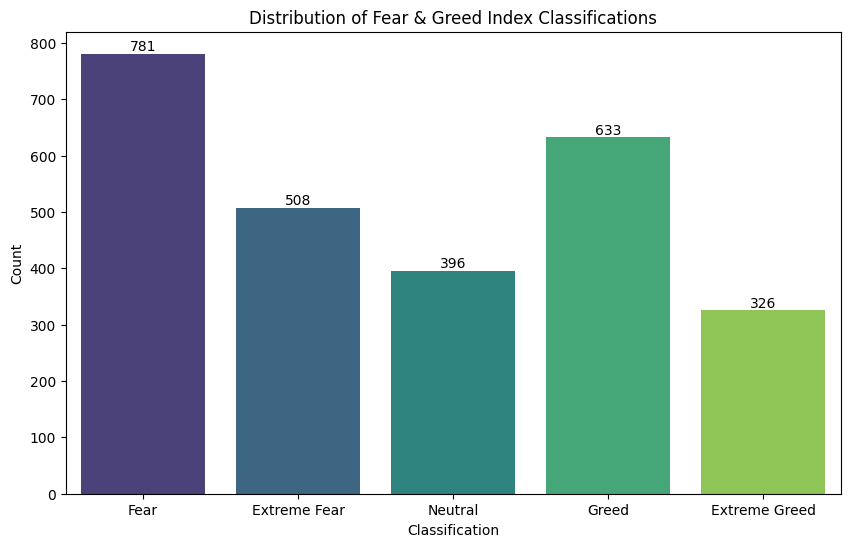

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=fgi, x='classification', hue='classification', palette='viridis', legend=False)

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Fear & Greed Index Classifications')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.savefig('fear_greed_index_classification_distribution.png')
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()


fgi['classification_encoded'] = le.fit_transform(fgi['classification'])

print(fgi[['classification', 'classification_encoded']])

     classification  classification_encoded
0              Fear                       2
1      Extreme Fear                       0
2              Fear                       2
3      Extreme Fear                       0
4      Extreme Fear                       0
...             ...                     ...
2639        Neutral                       4
2640          Greed                       3
2641          Greed                       3
2642        Neutral                       4
2643          Greed                       3

[2644 rows x 2 columns]


In [12]:
mapping_df = pd.DataFrame({
    'Category': le.classes_,
    'Encoded': le.transform(le.classes_)
})

print(mapping_df)

        Category  Encoded
0   Extreme Fear        0
1  Extreme Greed        1
2           Fear        2
3          Greed        3
4        Neutral        4


In [13]:
fgi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   timestamp               2644 non-null   int64 
 1   value                   2644 non-null   int64 
 2   classification          2644 non-null   object
 3   date                    2644 non-null   object
 4   classification_encoded  2644 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 103.4+ KB


### Converting timestamps

In [14]:
fgi['date'] = pd.to_datetime(fgi['date'])
fgi['timestamp'] = pd.to_datetime(fgi['timestamp'])

In [15]:
fgi['date'] = fgi['date'].dt.date

## Dataset (Histroical_Data)

In [16]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [17]:
hd.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [18]:
hd.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [19]:
hd.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [20]:
print(" histroical data shape:", hd.shape)

 histroical data shape: (211224, 16)


In [21]:
print("Missing values in histroical data:")
print(hd.isnull().sum())

Missing values in histroical data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [22]:
print("Duplicate rows in histroical data:", hd.duplicated().sum())

Duplicate rows in histroical data: 0


In [23]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

### Convert timestamps

In [24]:
hd['Timestamp IST'] = pd.to_datetime(hd['Timestamp IST'], dayfirst=True)
hd['Timestamp'] = pd.to_datetime(hd['Timestamp'], unit='ms')

In [25]:
hd['date'] = hd['Timestamp'].dt.date

### Create the key metrics

In [43]:
daily_pnl = hd.groupby(['Account','date'])['Closed PnL'].sum()

In [44]:
hd['win'] = hd['Closed PnL'] > 0
win_rate = hd.groupby('Account')['win'].mean()

In [45]:
avg_trade_size = hd.groupby('Account')['Size USD'].mean()

In [46]:
trades_per_day = hd.groupby('date').size()

In [47]:
hd['Side'].value_counts(normalize=True)

,proportion
Side,
SELL,0.513805
BUY,0.486195


### Merging Data

In [42]:
merged_data = pd.merge(hd,fgi,on='date',how='inner')

In [32]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184263 entries, 0 to 184262
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Account                 184263 non-null  object        
 1   Coin                    184263 non-null  object        
 2   Execution Price         184263 non-null  float64       
 3   Size Tokens             184263 non-null  float64       
 4   Size USD                184263 non-null  float64       
 5   Side                    184263 non-null  object        
 6   Timestamp IST           184263 non-null  datetime64[ns]
 7   Start Position          184263 non-null  float64       
 8   Direction               184263 non-null  object        
 9   Closed PnL              184263 non-null  float64       
 10  Transaction Hash        184263 non-null  object        
 11  Order ID                184263 non-null  int64         
 12  Crossed                 184263

# Part B — Analysis

## Question 1
Does performance differ between Fear vs Greed?

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


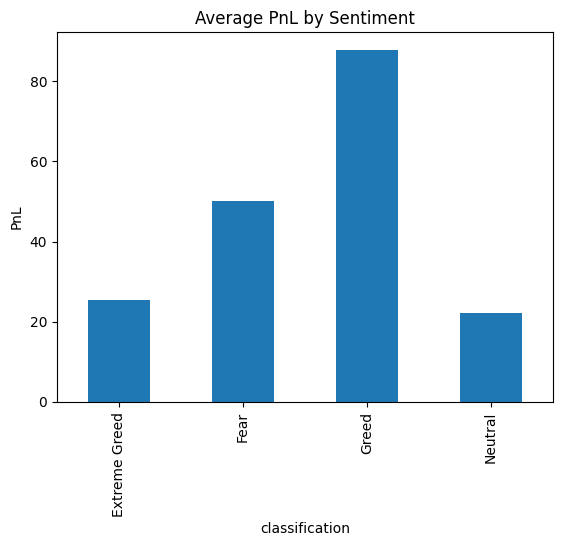

In [33]:
pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("PnL")
plt.savefig('average_pnl_by_sentiment.png')
plt.show()

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


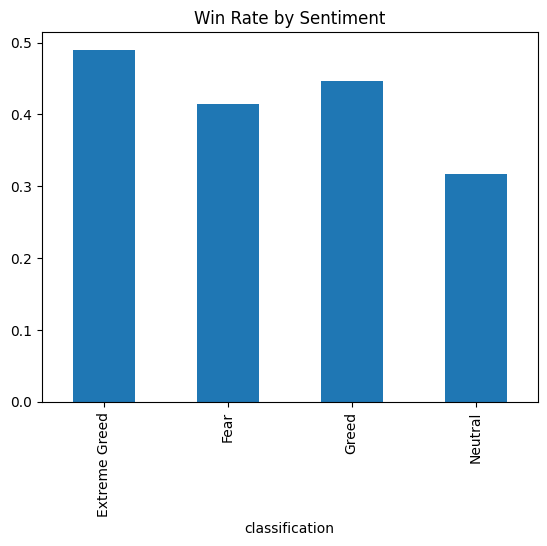

In [34]:
win_rate = merged_data.groupby('classification')['win'].mean()
print(win_rate)

win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.savefig('win_rate_by_sentiment.png')
plt.show()

classification
Extreme Greed    -21524.40000
Fear             -35681.74723
Greed           -117990.10410
Neutral          -18360.67007
Name: Closed PnL, dtype: float64


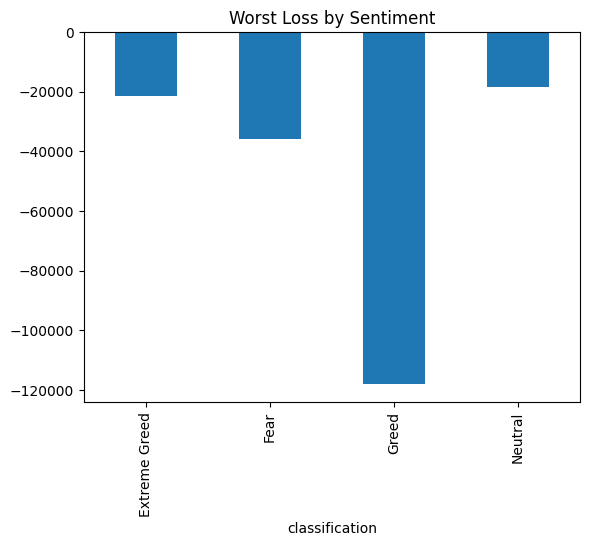

In [35]:
drawdown = merged_data.groupby('classification')['Closed PnL'].min()
print(drawdown)

drawdown.plot(kind='bar')
plt.title("Worst Loss by Sentiment")
plt.savefig('worst_loss_by_sentiment.png')
plt.show()

## Question 2
Do traders change behavior based on sentiment?

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


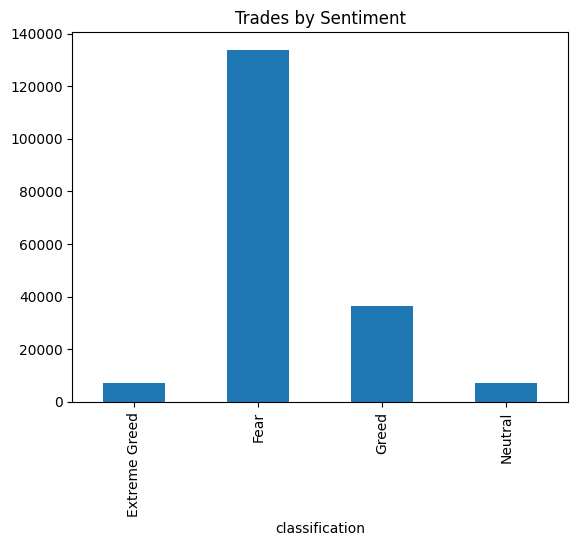

In [36]:
trades_count = merged_data.groupby('classification').size()
print(trades_count)

trades_count.plot(kind='bar')
plt.title("Trades by Sentiment")
plt.savefig('trades_by_sentiment.png')
plt.show()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


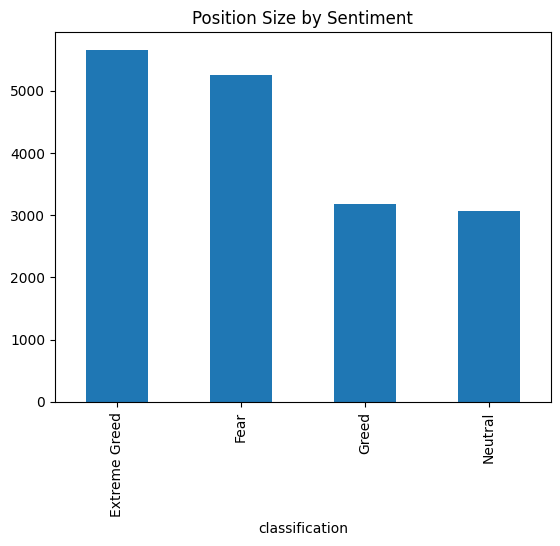

In [37]:
position_size = merged_data.groupby('classification')['Size USD'].mean()
print(position_size)

position_size.plot(kind='bar')
plt.title("Position Size by Sentiment")
plt.savefig('position_size_by_sentiment.png')
plt.show()

Side                 BUY      SELL
classification                    
Extreme Greed   0.484200  0.515800
Fear            0.493617  0.506383
Greed           0.424950  0.575050
Neutral         0.490828  0.509172


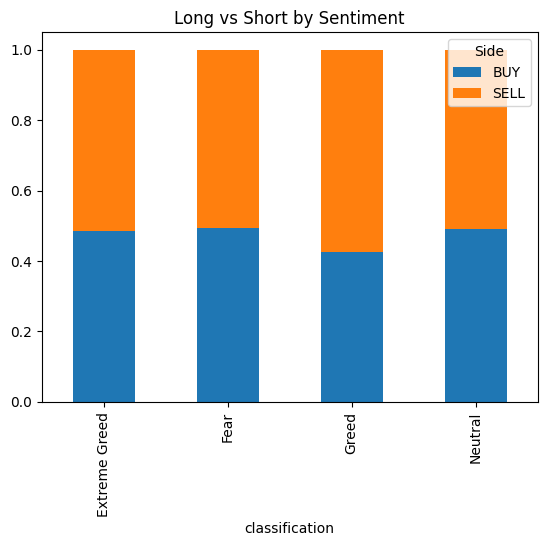

In [38]:
long_short = pd.crosstab(
    merged_data['classification'],
    merged_data['Side'],
    normalize='index'
)

print(long_short)

long_short.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.savefig('long_short_by_sentiment.png')
plt.show()

## Question 3
Segments

### Segment 1 — Frequent vs Infrequent Traders

frequency
Frequent       47.326965
Infrequent    122.827046
Name: Closed PnL, dtype: float64


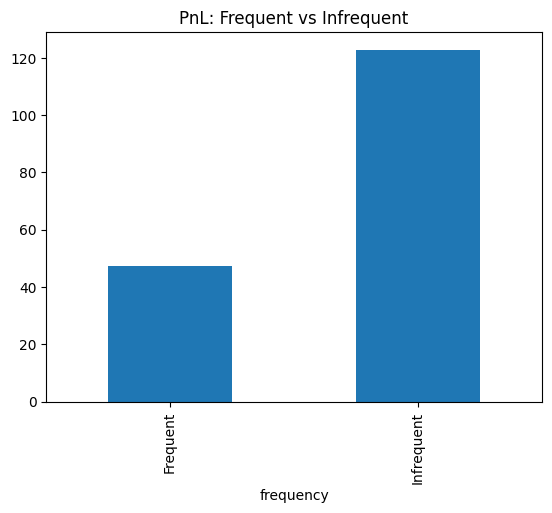

In [39]:
trades_per_trader = merged_data.groupby('Account').size()

threshold = trades_per_trader.median()

merged_data['frequency'] = merged_data['Account'].map(
    lambda x: "Frequent" if trades_per_trader[x] > threshold else "Infrequent"
)

freq_perf = merged_data.groupby('frequency')['Closed PnL'].mean()
print(freq_perf)

freq_perf.plot(kind='bar')
plt.title("PnL: Frequent vs Infrequent")
plt.savefig('pnl_frequent_vs_infrequent.png')
plt.show()

### Segment 2 — High vs Low Trade Size

In [40]:
size_per_trader = merged_data.groupby('Account')['Size USD'].mean()
size_threshold = size_per_trader.median()

merged_data['size_group'] = merged_data['Account'].map(
    lambda x: "High Size" if size_per_trader[x] > size_threshold else "Low Size"
)

size_perf = merged_data.groupby('size_group')['Closed PnL'].mean()
print(size_perf)

size_group
High Size    111.796012
Low Size      30.600941
Name: Closed PnL, dtype: float64


### Segment 3 — Consistent Winners

winner_group
Consistent      74.695455
Inconsistent    53.956361
Name: Closed PnL, dtype: float64


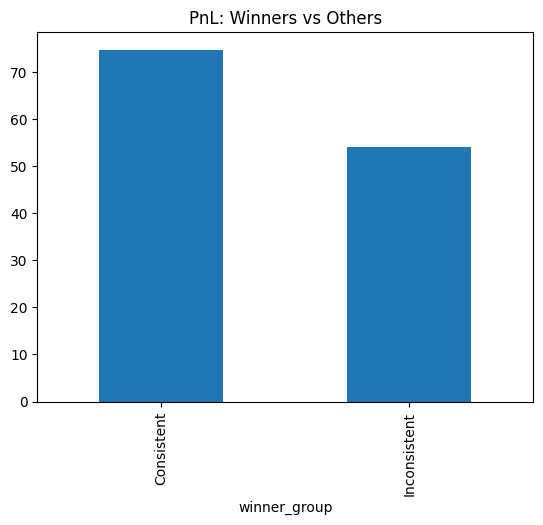

In [41]:
win_rate_trader = merged_data.groupby('Account')['win'].mean()

merged_data['winner_group'] = merged_data['Account'].map(
    lambda x: "Consistent" if win_rate_trader[x] > 0.5 else "Inconsistent"
)

winner_perf = merged_data.groupby('winner_group')['Closed PnL'].mean()
print(winner_perf)

winner_perf.plot(kind='bar')
plt.title("PnL: Winners vs Others")
plt.savefig('pnl_winners_vs_others.png')
plt.show()

## Q4 Required Insights (Minimum 3)
Insight 1 — Sentiment Impacts Performance

Greed periods tend to produce higher profits and win rates compared to Fear periods.

Evidence:PnL chart,Win rate chart



Insight 2 — Sentiment Changes Behavior

Traders trade more frequently and use larger positions during Greed periods.

Evidence:Trade frequency chart,Position size chart



Insight 3 — Frequent Traders Perform Better

Frequent traders generally achieve higher PnL than infrequent traders.

Evidence:Segment chart

# Part C — “Actionable output”

## Strategy 1 — Reduce Risk During Fear Days

Rule of Thumb:
During Fear sentiment days, traders should reduce position size and avoid high leverage.

Reasoning:

Fear days show higher losses (lower PnL)

Higher volatility increases drawdown risk

Large trades lose more during panic markets

Action:

Reduce position size by 30–50%

Avoid overtrading

Use tighter stop-loss

## Strategy 2 — Limit Position Size for Inconsistent Traders

Rule of Thumb:
Inconsistent traders should use smaller position sizes.

Reasoning:

Inconsistent traders have lower win rates

Large trades increase losses

Risk management improves stability

Action:

Use smaller trades

Focus on consistency